In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import os

## Exercise 13.3 (mandatory assignment 1)

### 13.3.1

#### Apply HP Filter with $\lambda=1600$ to data series for GDP, private consumption and private investment.

In [2]:
def apply_hp_filter(data, series_name, lambda_param=100):
    """
    Apply natural log transformation and Hodrick-Prescott filter to economic data.
    
    Parameters:
    -----------
    data : pandas.Series
        GDP, consumption and investment data series with years as index.
    country_name : str
        Name of the series for labeling.
    lambda_param : int
        Smoothing parameter for HP filter.
        
    Returns:
    --------
    tuple
        (cycle, trend) components from HP filter.
    """
    # Apply natural log transformation.
    log_data = np.log(data)
    
    # Apply HP filter to the log-transformed data.
    cycle, trend = hpfilter(log_data, lamb=lambda_param)
    
    # Create a figure with two subplots.
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))
    
    # Plot original log data and trend.
    ax1.plot(log_data.index, log_data, 'b-', label=f'Log {series_name}')
    ax1.plot(trend.index, trend, 'r-', label='Trend Component')
    ax1.set_title(f'Log {series_name} and Trend Component')
    ax1.set_xlabel('Year')
    ax1.set_ylabel(f'Log {series_name}')
    ax1.legend()
    ax1.grid(True)
    
    # Plot cyclical component (output gap).
    ax2.plot(cycle.index, 100*cycle, 'g-') # Multiply by 100 for percentage.
    ax2.set_title(f'Log {series_name} Cyclical Component')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Pct. Deviation from Trend')
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{series_name}_hp_filter_log.png')  # Save figure for reference.
    plt.show()  # Show the plot directly.
    
    return cycle, trend

In [3]:
# Read data. 
file_path = "Ex_13.3_dataset.xlsx"
sheet = "Sheet1"
skiprows = 10
nrows = 233

# Dataframes. 
quarters_df = pd.read_excel(file_path, sheet_name=sheet, usecols="A", skiprows=skiprows, 
                            header=None, names=["Quarter from"], nrows=nrows, parse_dates=True)
gdp_df = pd.read_excel(file_path, sheet_name=sheet, usecols="B", skiprows=skiprows, 
                       header=None, names=["GDP"], nrows=nrows)
pconsmpt_df = pd.read_excel(file_path, sheet_name=sheet, usecols="C", skiprows=skiprows, 
                            header=None, names=["Private Consumption"], nrows=nrows)
pinvest_df = pd.read_excel(file_path, sheet_name=sheet, usecols="D", skiprows=skiprows, 
                           header=None, names=["Private Investment"], nrows=nrows)
# Combine dataframes.
denmark_df = pd.concat([quarters_df, gdp_df, pconsmpt_df, pinvest_df], axis=1)

denmark_df.set_index("Quarter from", inplace=True)

In [4]:
print(f"Data from {denmark_df.index.min()} to {denmark_df.index.max()}")
print(f"Number of quarters = {len(denmark_df)}")
print(f"Number of years = {len(denmark_df)/4}")
print("\n Statistics:")
print(denmark_df.describe())

Data from 1966-01-01 00:00:00 to 2021-07-01 00:00:00
Number of quarters = 223
Number of years = 55.75

 Statistics:
                GDP  Private Consumption  Private Investment
count  2.230000e+02         2.230000e+02        2.230000e+02
mean   1.424183e+12         6.852422e+11        2.648648e+11
std    4.229514e+11         1.747893e+11        1.057230e+11
min    6.874472e+11         3.616644e+11        1.100992e+11
25%    1.045295e+12         5.396190e+11        1.712853e+11
50%    1.359620e+12         6.578268e+11        2.266996e+11
75%    1.824583e+12         8.591907e+11        3.406088e+11
max    2.228845e+12         1.017144e+12        5.189241e+11


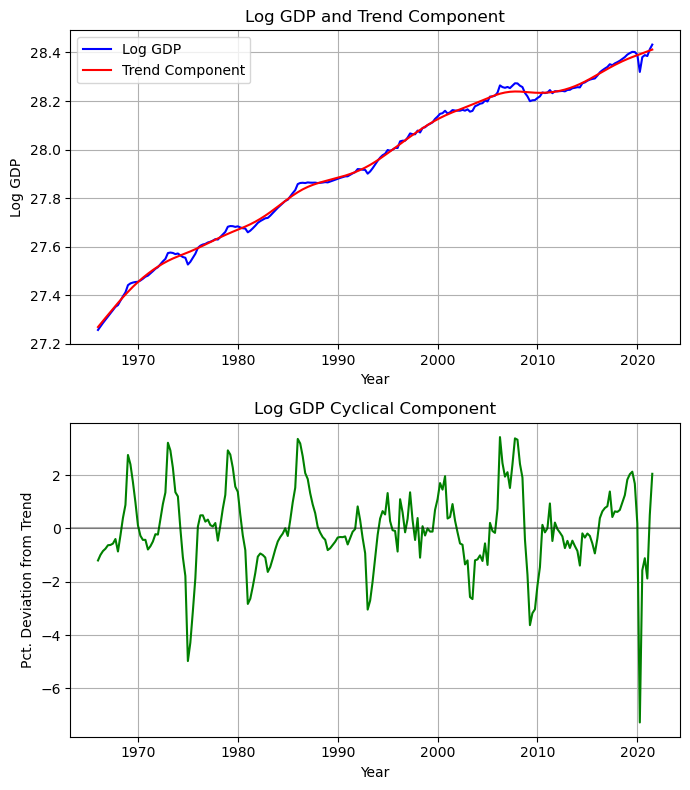

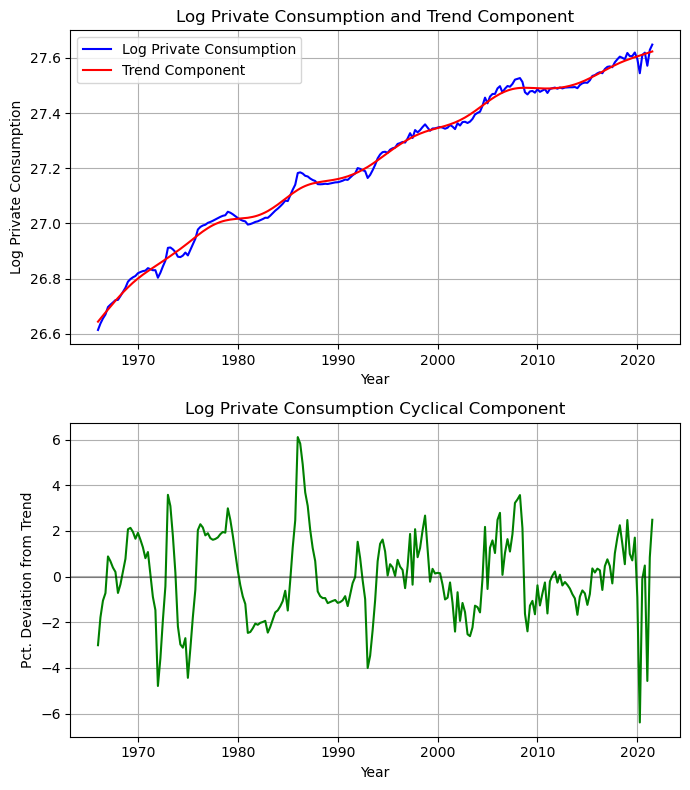

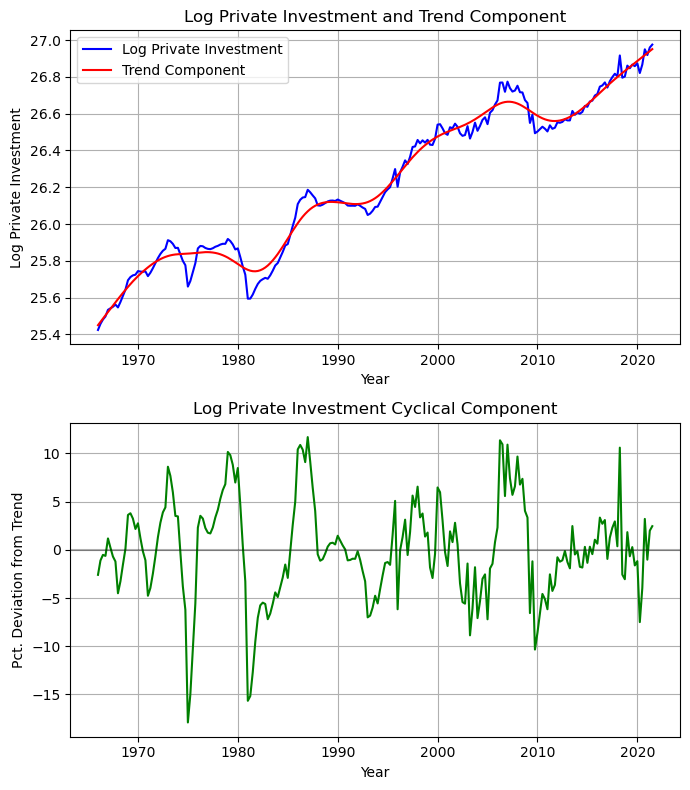

In [5]:
HP_results = {}
l = 1600 # Lambda parameter.
series = ["GDP", "Private Consumption", "Private Investment"]

for s in series: 
    cycle, trend = apply_hp_filter(denmark_df[s], s, lambda_param=l)

    denmark_series_df = pd.DataFrame({
        f"original {s}": denmark_df[s],
        f"log {s}": np.log(denmark_df[s]),
        f"{s} trend": trend, 
        f"{s} cycle": cycle, 
        f"pct. {s} cycle": cycle * 100
    })

    HP_results[s] = denmark_series_df

#### Comments
##### End points
- The log private consumption trend has an inaccurate starting point.
- In 2020 there are pronounced short-term declines in the original data series which the trends ignore.

##### Are the trends accurate?
- The trends fit fairly well. Private investment is the most volatile series with long peaks and troughs. These are more pronounced and long-lasting pre-1995. Post-1995, they are more short-term and volatile. 

### 13.3.2: Output gaps

The output gaps are the cyclical components plotted above.

$\ln(\textrm{GDP})-\ln(\textrm{Trend}_{\textrm{GDP}})\cdot 100$

In [6]:
HP_results["GDP"].describe()

,original GDP,log GDP,GDP trend,GDP cycle,pct. GDP cycle
count,2.230000e+02,223.000000,223.000000,2.230000e+02,2.230000e+02
mean,1.424183e+12,27.937427,27.937427,-3.177687e-13,-3.177687e-11
std,4.229514e+11,0.314292,0.313666,1.501004e-02,1.501004e+00
min,6.874472e+11,27.256251,27.268260,-7.282165e-02,-7.282165e+00
25%,1.045295e+12,27.675320,27.667495,-7.391890e-03,-7.391890e-01
50%,1.359620e+12,27.938227,27.949205,-1.243542e-03,-1.243542e-01
75%,1.824583e+12,28.232372,28.234144,7.979437e-03,7.979437e-01
max,2.228845e+12,28.432505,28.411981,3.430243e-02,3.430243e+00


#### Plot the three trends.

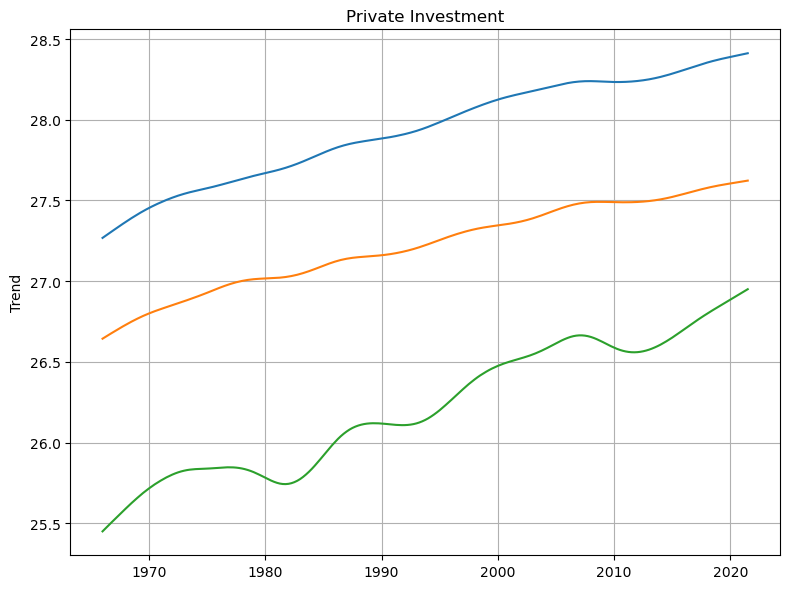

In [7]:
fig, ax = plt.subplots(figsize=(8,6))

for series, df in HP_results.items():
    ax.plot(df.index, df[f"{series} trend"], label=f"{series} Trend")
    ax.set_title(series)
    ax.set_ylabel("Trend")
    ax.grid(True)

plt.tight_layout()
plt.show()


##### Plot the gaps (cyclical components) together without the first and last 16 quarters.

In [8]:
HP_results = {
    series: df.iloc[16:-16].copy()
    for series, df in HP_results.items()
}

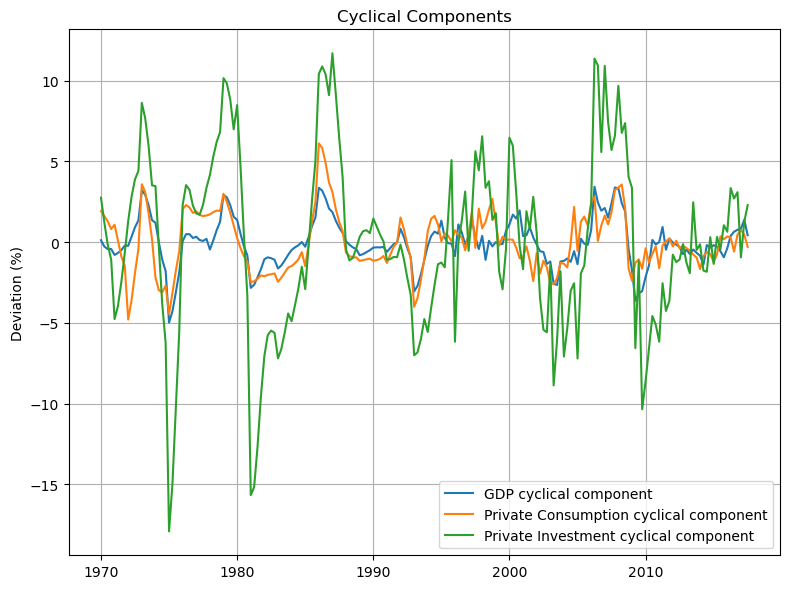

In [9]:
fig, ax = plt.subplots(figsize=(8,6))

for series, df in HP_results.items():
    ax.plot(df.index, df[f"pct. {series} cycle"], label=f"{series} cyclical component")
    ax.set_title("Cyclical Components")
    ax.set_ylabel("Deviation (%)")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()


##### Comments
- Private investments are far more volatile than GDP and consumption.

### 13.3.4: Correlation coefficients

Let $c_t$ be the cyclical component of $\ln(\textrm{GDP})$ and let $x_t$ be the log of a the cyclical component of a different series (consumption or investment).

In [11]:
# Compute the normalized coefficient of correlation.
def normal_corr_coef(c: pd.Series, x: pd.Series) -> float:
    x_dev = x - x.mean()
    c_dev = c - c.mean()
    num = x_dev @ c_dev # Use the dot-product operator to sum products. 
    denom = np.sqrt((x_dev @ x_dev) * (c_dev @ c_dev))
    return num/denom


Calculate all the correlation coefficients.

In [14]:
shifts = [-2, -1, 0, 1, 2]
coef_results = []

for key in ["Private Consumption", "Private Investment"]:
    series_cycle = HP_results[key][f"{key} cycle"]
    gdp_cycle = HP_results["GDP"]["GDP cycle"]

    row = {"Series": key}
    for lag in shifts:
        series_shift = series_cycle.shift(lag)
        series_align, gdp_align = series_shift.align(gdp_cycle, join="inner")
        non_na = pd.concat([series_align, gdp_align], axis=1).dropna()

        row[lag] = normal_corr_coef(non_na.iloc[:, 0], non_na.iloc[:, 1])

    coef_results.append(row)


df_coefs = (pd.DataFrame(coef_results)
            .set_index("Series")[shifts]
            .rename_axis("Lag", axis=1)
)

print(df_coefs)

Lag                        -2        -1         0         1         2
Series                                                               
Private Consumption  0.428232  0.583668  0.723296  0.691311  0.577577
Private Investment   0.676822  0.782223  0.846402  0.700358  0.561520
